In [ ]:
import pandas as pd
import glob
files = glob.glob("PRSA_Data_*.csv")
df1 = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)
df1.head(15)

In [113]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 420768 entries, 0 to 420767
Data columns (total 19 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   No        420768 non-null  int64         
 1   year      420768 non-null  int64         
 2   month     420768 non-null  int64         
 3   day       420768 non-null  int64         
 4   hour      420768 non-null  int64         
 5   PM2.5     412029 non-null  float64       
 6   PM10      414319 non-null  float64       
 7   SO2       411747 non-null  float64       
 8   NO2       408652 non-null  float64       
 9   CO        400067 non-null  float64       
 10  O3        407491 non-null  float64       
 11  TEMP      420370 non-null  float64       
 12  PRES      420375 non-null  float64       
 13  DEWP      420365 non-null  float64       
 14  RAIN      420378 non-null  float64       
 15  wd        418946 non-null  object        
 16  WSPM      420450 non-null  float64       
 

In [114]:
df1.shape

(420768, 19)

In [51]:
df1.isna().sum()

No             0
year           0
month          0
day            0
hour           0
PM2.5       8739
PM10        6449
SO2         9021
NO2        12116
CO         20701
O3         13277
TEMP         398
PRES         393
DEWP         403
RAIN         390
wd          1822
WSPM         318
station        0
dtype: int64

In [56]:
df1.isna().mean() * 100

No         0.0
year       0.0
month      0.0
day        0.0
hour       0.0
PM2.5      0.0
PM10       0.0
SO2        0.0
NO2        0.0
CO         0.0
O3         0.0
TEMP       0.0
PRES       0.0
DEWP       0.0
RAIN       0.0
wd         0.0
WSPM       0.0
station    0.0
dtype: float64

In [ ]:
df1.dropna(subset=['PM2.5'], inplace=True)
df1 = df1[df1.isna().mean(axis=1) < 0.3]

In [115]:
df1.sort_values(by=['year','month','day','hour'], inplace=True)

df1.ffill(inplace=True)  # forward fill
df1.bfill(inplace=True)  # backward fill
df1.dropna(inplace=True)

In [116]:
df1.describe().T

,count,mean,min,25%,50%,75%,max,std
No,420768.0,17532.5,1.0,8766.75,17532.5,26298.25,35064.0,10122.116943
year,420768.0,2014.66256,2013.0,2014.0,2015.0,2016.0,2017.0,1.177198
month,420768.0,6.52293,1.0,4.0,7.0,10.0,12.0,3.448707
day,420768.0,15.729637,1.0,8.0,16.0,23.0,31.0,8.800102
hour,420768.0,11.5,0.0,5.75,11.5,17.25,23.0,6.922195
PM2.5,420768.0,79.82185,2.0,20.0,55.0,111.0,999.0,81.023413
PM10,420768.0,104.784561,2.0,36.0,82.0,145.0,999.0,92.366241
SO2,420768.0,15.876263,0.2856,3.0,7.0,20.0,500.0,21.742454
NO2,420768.0,50.652189,1.0265,23.0,43.0,71.0,290.0,35.249779
CO,420768.0,1232.943161,100.0,500.0,900.0,1500.0,10000.0,1166.546597


In [117]:
df1[['PM2.5','PM10','SO2','NO2','CO','O3']].agg(['mean','std','min','max','median']).T

,mean,std,min,max,median
PM2.5,79.821850,81.023413,2.0000,999.0,55.0
PM10,104.784561,92.366241,2.0000,999.0,82.0
SO2,15.876263,21.742454,0.2856,500.0,7.0
NO2,50.652189,35.249779,1.0265,290.0,43.0
CO,1232.943161,1166.546597,100.0000,10000.0,900.0
O3,57.024342,56.591103,0.2142,1071.0,44.0


In [118]:
df1[df1['station']=='Changping']

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,datetime
105192,1,2013,3,1,0,3.0,6.0,13.0,7.0,300.0,85.0,-2.3,1020.8,-19.7,0.0,E,0.5,Changping,2013-03-01 00:00:00
105193,2,2013,3,1,1,3.0,3.0,6.0,6.0,300.0,85.0,-2.5,1021.3,-19.0,0.0,ENE,0.7,Changping,2013-03-01 01:00:00
105194,3,2013,3,1,2,3.0,3.0,22.0,13.0,400.0,74.0,-3.0,1021.3,-19.9,0.0,ENE,0.2,Changping,2013-03-01 02:00:00
105195,4,2013,3,1,3,3.0,6.0,12.0,8.0,300.0,81.0,-3.6,1021.8,-19.1,0.0,NNE,1.0,Changping,2013-03-01 03:00:00
105196,5,2013,3,1,4,3.0,3.0,14.0,8.0,300.0,81.0,-3.5,1022.3,-19.4,0.0,N,2.1,Changping,2013-03-01 04:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
140251,35060,2017,2,28,19,28.0,47.0,4.0,14.0,300.0,86.0,11.7,1008.9,-13.3,0.0,NNE,1.3,Changping,2017-02-28 19:00:00
140252,35061,2017,2,28,20,12.0,12.0,3.0,23.0,500.0,64.0,10.9,1009.0,-14.0,0.0,N,2.1,Changping,2017-02-28 20:00:00
140253,35062,2017,2,28,21,7.0,23.0,5.0,17.0,500.0,68.0,9.5,1009.4,-13.0,0.0,N,1.5,Changping,2017-02-28 21:00:00
140254,35063,2017,2,28,22,11.0,20.0,3.0,15.0,500.0,72.0,7.8,1009.6,-12.6,0.0,NW,1.4,Changping,2017-02-28 22:00:00


In [119]:
df1[df1['station'].isin(['Aotizhongxin','Dingling'])]

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,datetime
350640,1,2013,3,1,0,4.0,4.0,3.0,2.0,200.0,82.0,-2.3,1020.8,-19.7,0.0,E,0.5,Dingling,2013-03-01 00:00:00
315576,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin,2013-03-01 00:00:00
350641,2,2013,3,1,1,7.0,7.0,3.0,9.0,200.0,80.0,-2.5,1021.3,-19.0,0.0,ENE,0.7,Dingling,2013-03-01 01:00:00
315577,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin,2013-03-01 01:00:00
350642,3,2013,3,1,2,5.0,5.0,3.0,2.0,200.0,79.0,-3.0,1021.3,-19.9,0.0,ENE,0.2,Dingling,2013-03-01 02:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
385701,35062,2017,2,28,21,9.0,14.0,2.0,2.0,200.0,102.0,9.5,1009.4,-13.0,0.0,N,1.5,Dingling,2017-02-28 21:00:00
385702,35063,2017,2,28,22,10.0,12.0,2.0,2.0,200.0,97.0,7.8,1009.6,-12.6,0.0,NW,1.4,Dingling,2017-02-28 22:00:00
350638,35063,2017,2,28,22,21.0,44.0,12.0,87.0,700.0,35.0,10.5,1014.4,-12.9,0.0,NNW,1.2,Aotizhongxin,2017-02-28 22:00:00
350639,35064,2017,2,28,23,19.0,31.0,10.0,79.0,600.0,42.0,8.6,1014.1,-15.9,0.0,NNE,1.3,Aotizhongxin,2017-02-28 23:00:00


In [120]:
df1.groupby('station')[['PM2.5','PM10','SO2','NO2','CO','O3']].mean().sort_values(by='PM2.5', ascending=False)

,PM2.5,PM10,SO2,NO2,CO,O3
station,,,,,,
Dongsi,86.083108,110.271569,18.455704,53.838371,1321.213666,57.532581
Wanshouxigong,84.986331,112.376201,17.253467,55.526708,1366.239590,55.700347
Nongzhanguan,84.768851,109.127786,18.693255,58.013448,1324.501939,58.454910
Gucheng,84.068982,119.000342,15.429047,55.889145,1324.285079,57.481151
Wanliu,83.415124,110.616664,18.349483,64.665897,1321.121948,47.491506
Guanyuan,82.917291,109.046404,17.599438,57.870927,1270.418948,54.962034
Aotizhongxin,82.555422,110.043783,17.526525,59.228413,1270.995494,55.283241
Tiantan,82.063421,106.521752,14.551747,53.193153,1301.968001,55.837795
Shunyi,79.329517,98.992049,13.517504,44.134145,1181.102669,55.123828


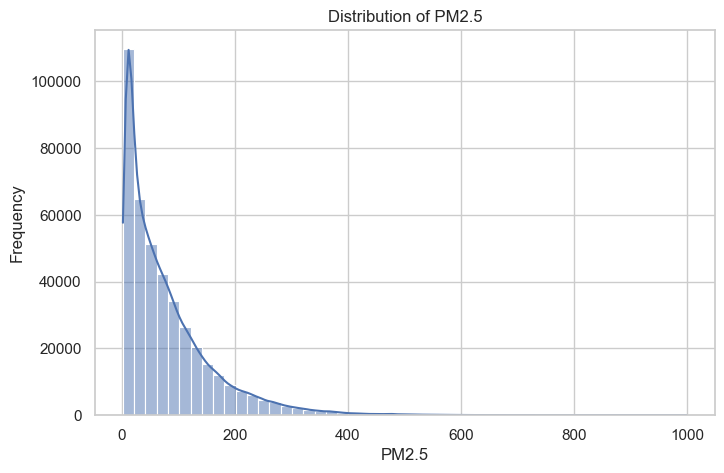

In [121]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

plt.figure(figsize=(8,5))
sns.histplot(df1['PM2.5'], bins=50, kde=True)

plt.title('Distribution of PM2.5')
plt.xlabel('PM2.5')
plt.ylabel('Frequency')

plt.show()

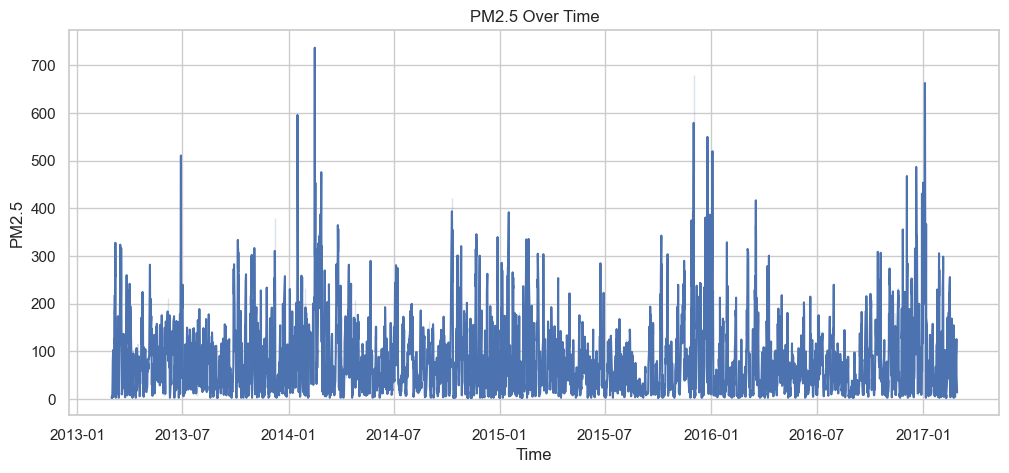

In [128]:
df_sample = df1.sample(5000)
df_sample['datetime']=pd.to_datetime(df_sample[['year','month','day','hour']])
df_sample=df_sample.sort_values('datetime')
plt.figure(figsize=(12,5))
sns.lineplot(x='datetime', y='PM2.5', data=df_sample)

plt.title('PM2.5 Over Time')
plt.xlabel('Time')
plt.ylabel('PM2.5')

plt.show()

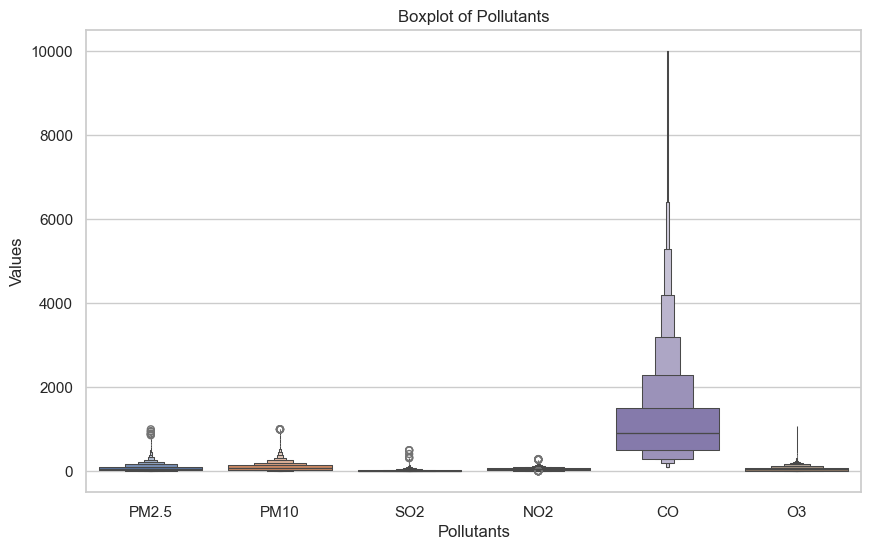

In [125]:
plt.figure(figsize=(10,6))
sns.boxenplot(data=df1[['PM2.5','PM10','SO2','NO2','CO','O3']])
plt.title('Boxplot of Pollutants')
plt.xlabel('Pollutants')
plt.ylabel('Values')
plt.show()

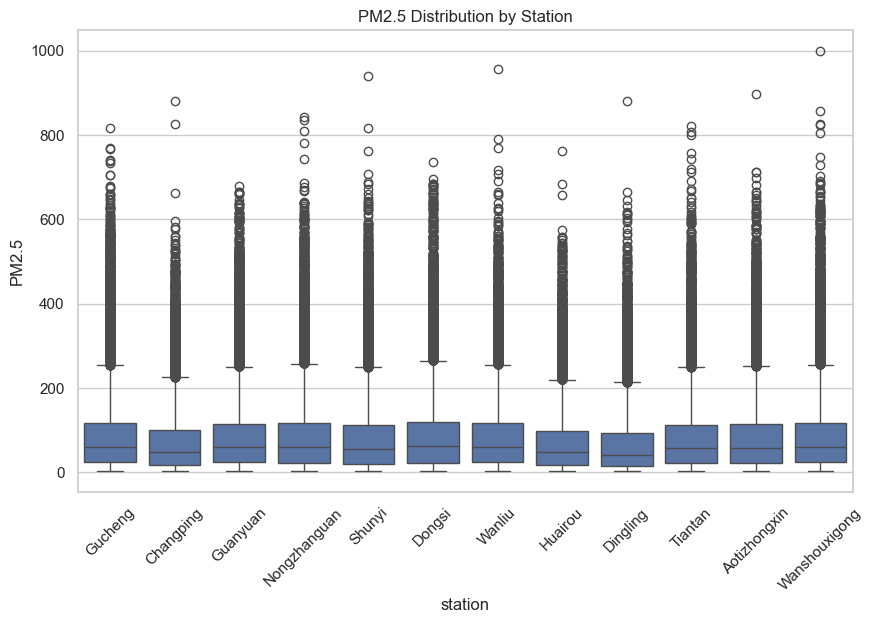

In [127]:
plt.figure(figsize=(10,6))
sns.boxplot(x='station',y='PM2.5',data=df1)
plt.xticks(rotation=45)
plt.title('PM2.5 Distribution by Station')

plt.show()

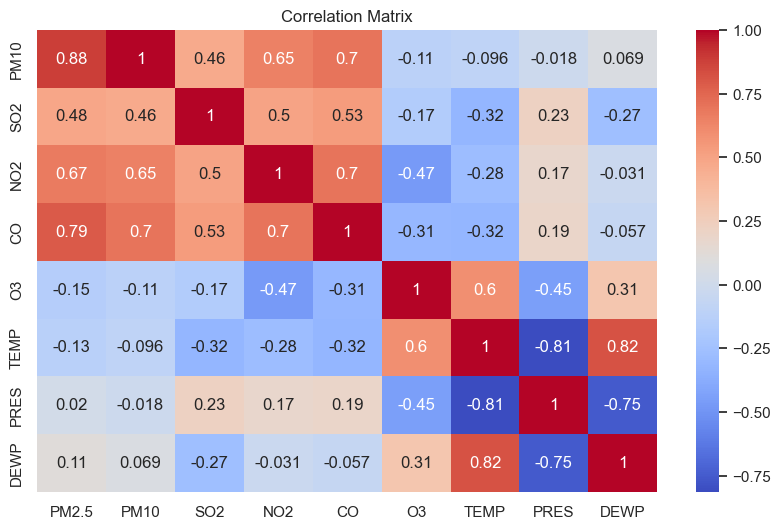

In [155]:
corr = df1[['PM2.5','PM10','SO2','NO2','CO','O3','TEMP','PRES','DEWP']].corr().drop('PM2.5')
corr['PM2.5'].sort_values(ascending=False)
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title('Correlation Matrix')
plt.show()

In [156]:
corr = df1[['PM2.5','PM10','SO2','NO2','CO','O3','TEMP','PRES','DEWP']].corr()
corr['PM2.5'].sort_values(ascending=False)

PM2.5    1.000000
PM10     0.881158
CO       0.787538
NO2      0.667128
SO2      0.484203
DEWP     0.113964
PRES     0.019758
TEMP    -0.131385
O3      -0.151033
Name: PM2.5, dtype: float64

In [157]:
corr_abs = corr['PM2.5'].drop('PM2.5').abs().sort_values(ascending=False)
print(corr_abs)

PM10    0.881158
CO      0.787538
NO2     0.667128
SO2     0.484203
O3      0.151033
TEMP    0.131385
DEWP    0.113964
PRES    0.019758
Name: PM2.5, dtype: float64


In [158]:
corr_df = corr['PM2.5'].drop('PM2.5').reset_index()
corr_df.columns = ['Variable', 'Correlation']
corr_df = corr_df.sort_values(by='Correlation', ascending=False)

print(corr_df)

  Variable  Correlation
0     PM10     0.881158
3       CO     0.787538
2      NO2     0.667128
1      SO2     0.484203
7     DEWP     0.113964
6     PRES     0.019758
5     TEMP    -0.131385
4       O3    -0.151033
